Chưa làm xong :)

In [1]:
import numpy as np

In [2]:
cau = [
    "I love eating pizza on weekends",
    "I enjoy having pizza every weekend",
    "The weather is very hot today",
    "It is extremely sunny this afternoon",
    "My cat likes sleeping on the sofa",
    "The kitten is resting on the couch",
    "Programming in Python is fun",
    "The airplane landed safely at the airport"
]

Ở bài số 1 em làm cho trường hợp là text

In [3]:
#1.1
vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in cau])

print(X.shape)

(8, 38)


Giải thích về X.shape : Xây dựng vocab từ list câu ta được 1 list toàn bộ các từ đã xuất hiện trong các câu, hàm to_vector() chuyển từng câu thành one-hot vector tương ứng, do đó mỗi dòng của X là ứng với 1 câu 
và mỗi cột thể hiên tần suất xuất hiện của các từ trong list vocab xuất hiện trong các câu 

In [4]:
# 1.2
X_mean = np.mean(X, axis=0)
print(f"X_mean.shape : {X_mean.shape}")
print(f"Before minus, X.shape : {X.shape}")
X_minus_Xmean = X - X_mean
print(f"After minus, X.shape : {X_minus_Xmean.shape}")

X_mean.shape : (38,)
Before minus, X.shape : (8, 38)
After minus, X.shape : (8, 38)


In [5]:
# 1.3
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

print(cosine_similarity(X))

[[1.         0.33333333 0.         0.         0.15430335 0.13608276
  0.         0.        ]
 [0.33333333 1.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         1.         0.16666667 0.15430335 0.40824829
  0.18257419 0.27216553]
 [0.         0.         0.16666667 1.         0.         0.13608276
  0.18257419 0.        ]
 [0.15430335 0.         0.15430335 0.         1.         0.37796447
  0.         0.25197632]
 [0.13608276 0.         0.40824829 0.13608276 0.37796447 1.
  0.1490712  0.44444444]
 [0.         0.         0.18257419 0.18257419 0.         0.1490712
  1.         0.        ]
 [0.         0.         0.27216553 0.         0.25197632 0.44444444
  0.         1.        ]]


Ma trận trên là ma trận tương đồng của X với chính nó, giá trị của phần tử a_ij là độ tương đồng theo cosine của câu thứ i và câu thứ j trong list cau ban đầu.

In [6]:
# 1.4
def search(query, top_k=3):
    query_vector = np.array([to_vector(query)])

    similar_score = cosine_similarity(
        query_vector,
        X
    )[0]

    top_k_sorted_indices = np.argsort(
        similar_score
    )[::-1][:top_k]

    results = [cau[i] for i in top_k_sorted_indices]

    return results, similar_score[top_k_sorted_indices]

sample_query = "I enjoy eating pizza"

a, b = search(sample_query)

for x, y in zip(a, b):
    print(f"{x} -> similar_score : {y}")
    

I enjoy having pizza every weekend -> similar_score : 0.6123724356957946
I love eating pizza on weekends -> similar_score : 0.6123724356957946
The airplane landed safely at the airport -> similar_score : 0.0


Em thực hiện chuyển câu query thông qua hàm to_vector sau đó gọi consine_similarity để tính ma trận tương đồng của vector query với data hiện có (list cau)
sau đó thực hiện sort để lấy ra top_k kết quả có score cao nhất,
Em chưa hiểu 1 chỗ là query này xử lý thế nào, nếu query là câu mà chứa từ chưa có trong vocab thì sẽ xảy ra lỗi 


In [7]:
print(f"Ma tran tuong dong X x X")

print(cosine_similarity(X))

Ma tran tuong dong X x X
[[1.         0.33333333 0.         0.         0.15430335 0.13608276
  0.         0.        ]
 [0.33333333 1.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         1.         0.16666667 0.15430335 0.40824829
  0.18257419 0.27216553]
 [0.         0.         0.16666667 1.         0.         0.13608276
  0.18257419 0.        ]
 [0.15430335 0.         0.15430335 0.         1.         0.37796447
  0.         0.25197632]
 [0.13608276 0.         0.40824829 0.13608276 0.37796447 1.
  0.1490712  0.44444444]
 [0.         0.         0.18257419 0.18257419 0.         0.1490712
  1.         0.        ]
 [0.         0.         0.27216553 0.         0.25197632 0.44444444
  0.         1.        ]]


Dựa vào ma trận tương đồng thì ta có câu 1 giống với câu 2 (score 0.33333), cặp khác biệt nhất là 1 và 3 và đúng với trực giác, điểm theo cosine không quá cao theo em bởi vì cách chuyển theo one-hot vector chỉ xét trên mặt chữ và yếu tố câu từ chứ không hiệu quả về mặt ngữ nghĩa

Bài 2B : Text

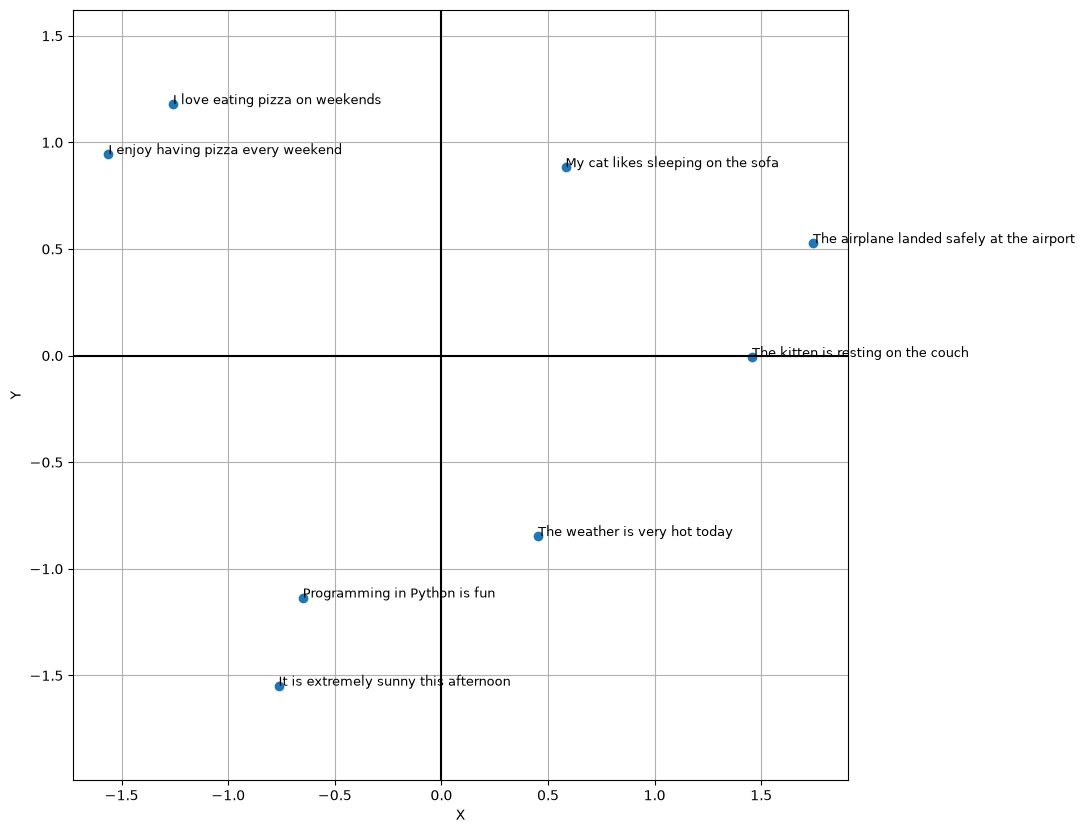

In [32]:
# 2B
X = np.array([to_vector(s) for s in cau]) 
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=True)

coords = U[:, :2] * S[:2]

# trực quan hoá
plt.figure(figsize=(10, 10))
plt.scatter(coords[:, :1], coords[:, 1:])
plt.axhline(y=0, color='black')
plt.axvline(x=0, color='black')
plt.grid(True)
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
for i, s in enumerate(cau):
    plt.text(coords[i, 0], coords[i, 1], s, fontsize=9)

Nhận xét : Các câu cùng chủ đề nằm gần nhau (các nhóm như pizza, cat, weather , việc center dữ liệu phương pháp giảm chiều (PCA) đã tìm ra trục mà ở đó dữ liệu có thể phân hoá mạnh hay có sự khác nhau lớn, và eigen ở đây là cách để tìm ra các trục này, tìm ra vector riêng và trị riêng của Ma trận tương quan của X với chính nó sẽ cho ta hướng và mức độ thay đổi phương sai của dữ liệu.

Mở rộng phần text

In [ ]:
# 1-NN
def 1_NN(query):
def search(query, top_k=3):
    query_vector = np.array([to_vector(query)])

    similar_score = cosine_similarity(
        query_vector,
        X
    )[0]

    top_k_sorted_indices = np.argsort(
        similar_score
    )[::-1][:top_k]

    results = [cau[i] for i in top_k_sorted_indices]

    return results, similar_score[top_k_sorted_indices]

Em muốn thử làm thêm phần Ảnh ở bài 2   :>

Điểm (1,0)


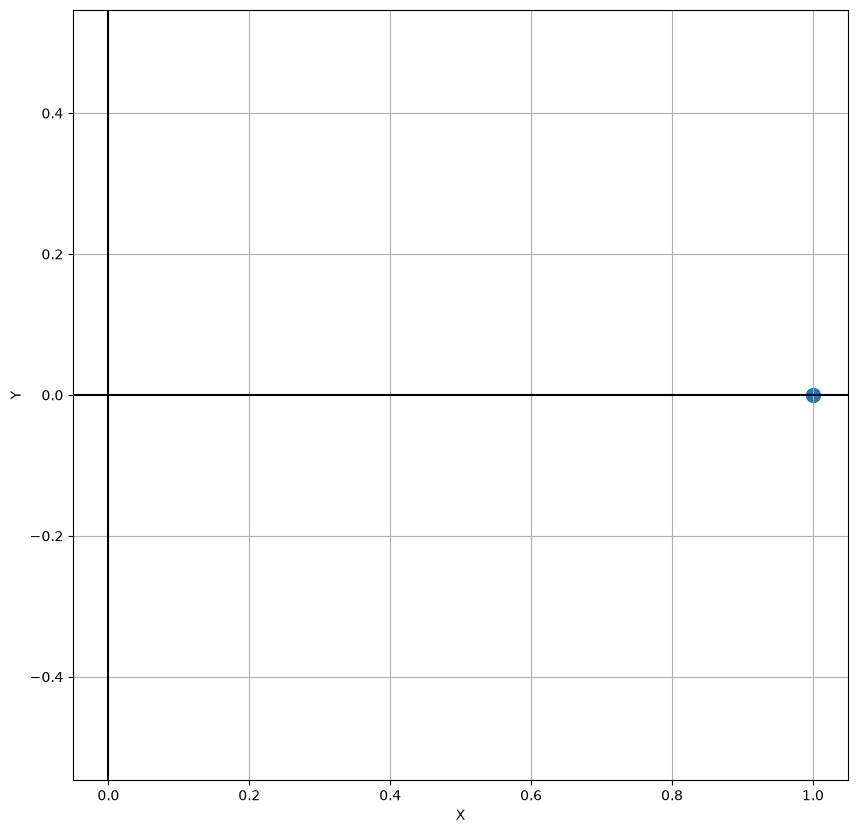

Thực hiện phép quay 90 độ cho điểm (1,0) -> (0,1)


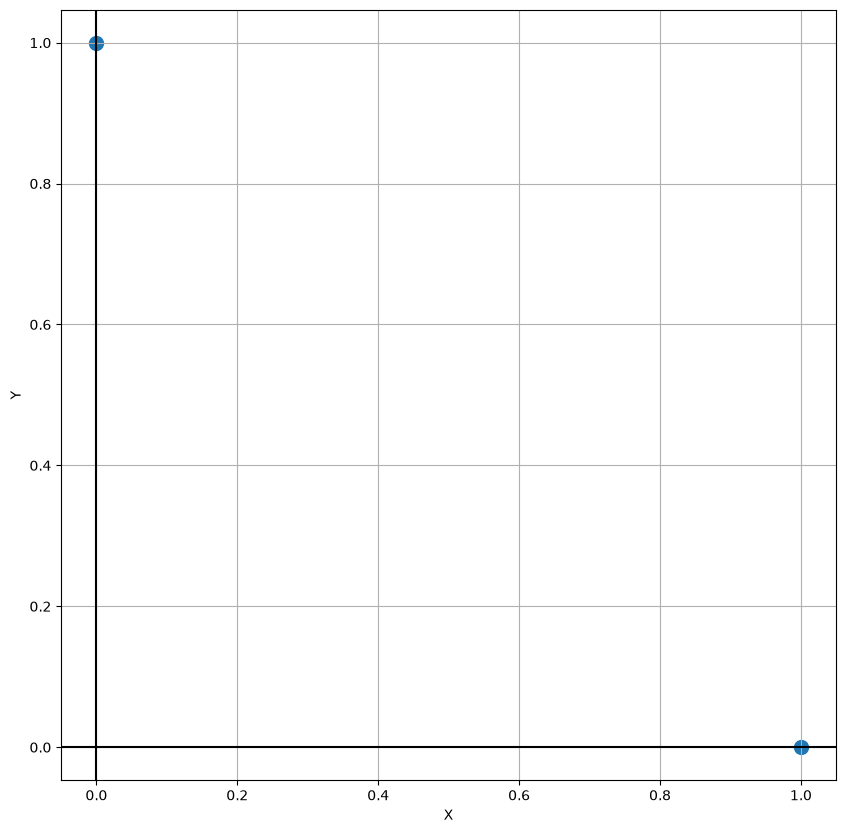

Áp dụng ma trận co giãn S cho điểm (1,1) -> (3,3)


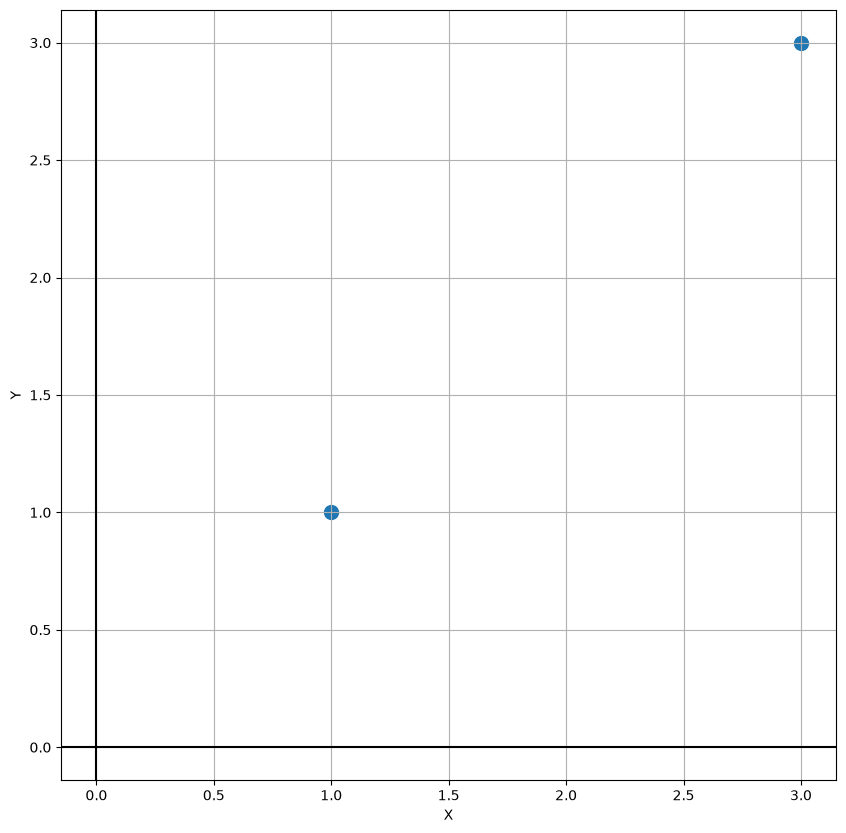

In [8]:
#2A.1 : Ảnh 
import matplotlib.pyplot as plt

def draw(x, y, color=None):
    plt.figure(figsize=(10, 10))
    plt.scatter(x, y, s=100)
    plt.axhline(y=0, color='black')
    plt.axvline(x=0, color='black')
    plt.grid(True)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis('equal')
    plt.show()


def R(theta):
    theta = np.deg2rad(theta)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

point = np.array([1,0])
print("Điểm (1,0)")
draw(point[0], point[1], "blue")
rotated_point = R(90) @ point
print("Thực hiện phép quay 90 độ cho điểm (1,0) -> (0,1)")
draw([point[0], rotated_point[0]], [point[1], rotated_point[1]], "red")

S = np.array([
    [3, 0],
    [0, 3]
])

point_2 = np.array([1,1])
streched_point =  S @ point_2 
print("Áp dụng ma trận co giãn S cho điểm (1,1) -> (3,3)")
draw([point_2[0], streched_point[0]], [point_2[1], streched_point[1]], "red")


In [11]:
M = np.array(Image.open("cat.jpg").convert("L"), dtype="float")

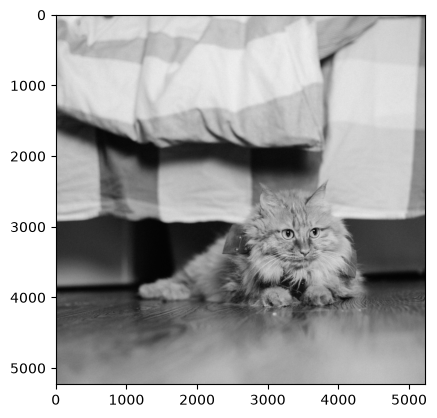

In [12]:
#2A.2
from PIL import Image

plt.imshow(M, cmap="gray")
U, S, Vt = np.linalg.svd(M, full_matrices=True)


In [14]:
def reconstruct(k):
    return (U[:,:k] * S[:k]) @ Vt[:k, :]

thử nghiệm giảm chiều ảnh với hệ số k lần lượt bằng 5, 20, 50

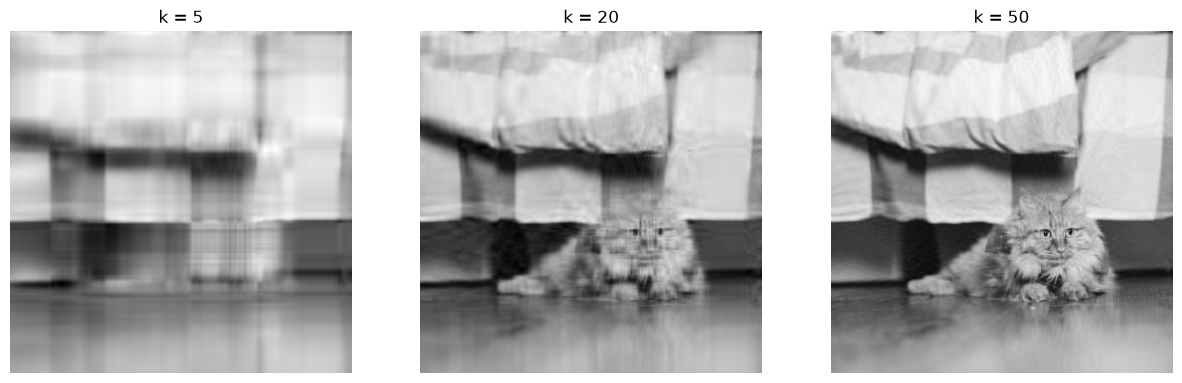

In [18]:
re5 = reconstruct(5)
re20 = reconstruct(20)
re50 = reconstruct(50)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(re5, cmap="gray")
plt.title("k = 5")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(re20, cmap="gray")
plt.title("k = 20")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(re50, cmap="gray")
plt.title("k = 50")
plt.axis("off")

plt.show()
